In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("UpdatedResumeDataSet.csv")
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [11]:
df.shape

(962, 2)

In [12]:
df['Category'].value_counts()

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Data Science                 40
Mechanical Engineer          40
Sales                        40
Operations Manager           40
ETL Developer                40
Blockchain                   40
Arts                         36
Database                     33
Health and fitness           30
Electrical Engineering       30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64

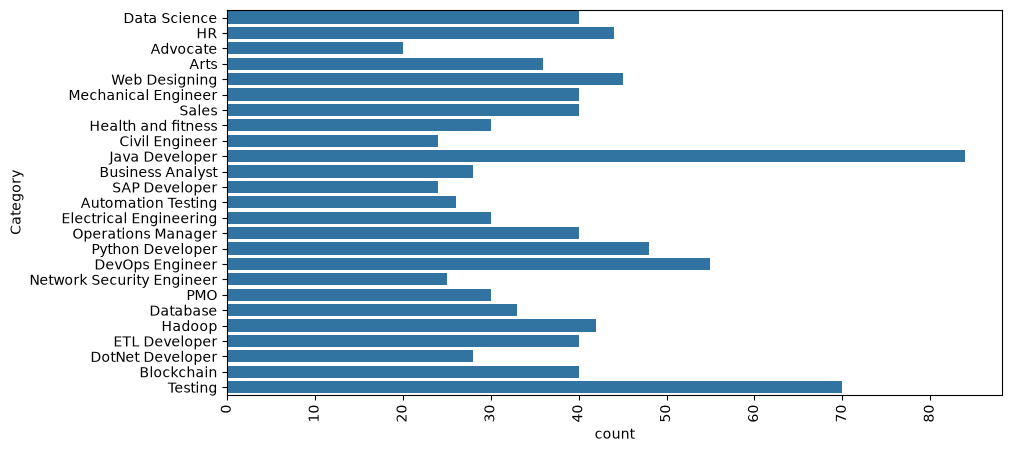

In [13]:
plt.figure(figsize=(10,5))
sns.countplot(df['Category'])
plt.xticks(rotation=90)
plt.show()

In [14]:
df['Category'].unique()

<ArrowStringArray>
[             'Data Science',                        'HR',
                  'Advocate',                      'Arts',
             'Web Designing',       'Mechanical Engineer',
                     'Sales',        'Health and fitness',
            'Civil Engineer',            'Java Developer',
          'Business Analyst',             'SAP Developer',
        'Automation Testing',    'Electrical Engineering',
        'Operations Manager',          'Python Developer',
           'DevOps Engineer', 'Network Security Engineer',
                       'PMO',                  'Database',
                    'Hadoop',             'ETL Developer',
          'DotNet Developer',                'Blockchain',
                   'Testing']
Length: 25, dtype: str

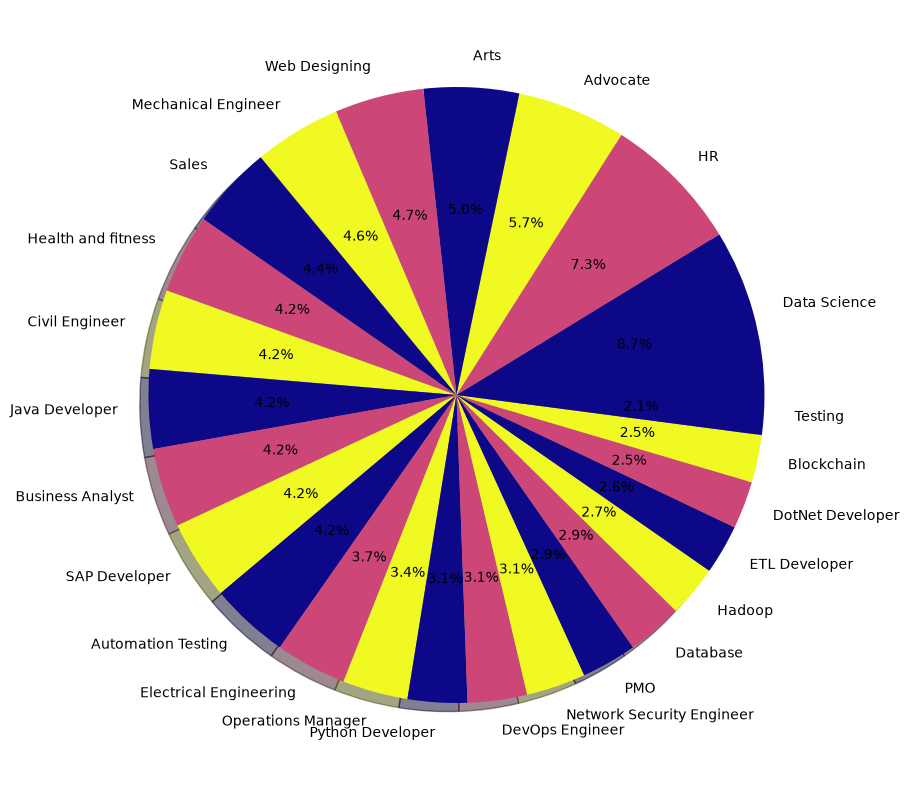

In [15]:
counts = df['Category'].value_counts()
labels = df['Category'].unique()
plt.figure(figsize=(15,10))
plt.pie(counts,labels=labels,autopct='%1.1f%%',shadow=True, colors=plt.cm.plasma(np.linspace(0,1,3)))
plt.show()

## Resume Exploring

In [16]:
df['Category'][0]

'Data Science'

In [17]:
df['Resume'][0]

'Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details \r\n\r\nData Science Assurance Associate \r\n\r\nData Science Assurance Associate - Ernst & Young LLP\r\nSkill Details \r\nJAVASCRIPT- Exprience - 24 months\r\njQuery- Exprience - 24 months\r\nPython- Exprience - 24 monthsCompany Details \r\ncompany - Ernst & Young LLP\r\ndescription - Fraud Investigatio

## Cleaning Data:
#### URLs,Hashtags(#),Mentions,Special Letters,Punctuation

In [18]:
import re #search, match, extract, replace, and clean text
def CleanResume(txt):
    cleanTxt = re.sub('http\S+\s'," ",txt) #find URLs or HTTP links in text so they can be removed during text cleaning.
    cleanTxt = re.sub('@\S+'," ",cleanTxt) #Removing mentions/usernames
    cleanTxt = re.sub('#\S+'," ",cleanTxt) #Removing hashtags
    cleanTxt = re.sub('RT|CC'," ",cleanTxt) #Removing the words RT or CC
    cleanTxt = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~""")," ",cleanTxt)
    cleanTxt = re.sub(r'[^\x00-\x7f]'," ",cleanTxt) #Removing non-ASCII characters. ' é '
    cleanTxt = re.sub('\s+'," ",cleanTxt) #Removing/replacing multiple spaces, tabs, and new lines.
    return cleanTxt

In [19]:
CleanResume("My ### $ #sandy website like is this http://helloworld and acces it @gmail.com this email")

'My website like is this and acces it this email'

In [20]:
df['Resume'] = df['Resume'].apply(lambda x: CleanResume(x))

In [21]:
df['Resume'][0]

'Skills Programming Languages Python pandas numpy scipy scikit learn matplotlib Sql Java JavaScript JQuery Machine learning Regression SVM Na ve Bayes KNN Random Forest Decision Trees Boosting techniques Cluster Analysis Word Embedding Sentiment Analysis Natural Language processing Dimensionality reduction Topic Modelling LDA NMF PCA Neural Nets Database Visualizations Mysql SqlServer Cassandra Hbase ElasticSearch D3 js DC js Plotly kibana matplotlib ggplot Tableau Others Regular Expression HTML CSS Angular 6 Logstash Kafka Python Flask Git Docker computer vision Open CV and understanding of Deep learning Education Details Data Science Assurance Associate Data Science Assurance Associate Ernst Young LLP Skill Details JAVASCRIPT Exprience 24 months jQuery Exprience 24 months Python Exprience 24 monthsCompany Details company Ernst Young LLP description Fraud Investigations and Dispute Services Assurance TECHNOLOGY ASSISTED REVIEW TAR Technology Assisted Review assists in accelerating the

## Words into Categorical values

In [22]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [23]:
le.fit(df['Category'])
df['Category'] = le.transform(df['Category'])

In [24]:
df.Category.unique()

array([ 6, 12,  0,  1, 24, 16, 22, 14,  5, 15,  4, 21,  2, 11, 18, 20,  8,
       17, 19,  7, 13, 10,  9,  3, 23])

In [25]:
#'Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
# 'Mechanical Engineer', 'Sales', 'Health and fitness',
# 'Civil Engineer', 'Java Developer', 'Business Analyst',
#'SAP Developer', 'Automation Testing', 'Electrical Engineering',
#'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
#'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],


## Vactorization

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english')

tfidf.fit(df['Resume'])
requiredText = tfidf.transform(df['Resume'])

In [27]:
requiredText

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 164062 stored elements and shape (962, 7339)>

## Splitting

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(requiredText, df['Category'], test_size = 0.2, random_state = 42)

In [30]:
X_train.shape

(769, 7339)

In [31]:
X_test.shape

(193, 7339)

## Now let's train the model and print the classification report:

In [32]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score

clf = OneVsRestClassifier(KNeighborsClassifier())
clf.fit(X_train,y_train)
ypred = clf.predict(X_test)
accuracy = accuracy_score(y_test,ypred)
print("Accuracy:", accuracy * 100, "%")

Accuracy: 98.44559585492227 %


## Prediction System

In [33]:
import pickle
pickle.dump(tfidf,open('tfidf.pkl','wb'))
pickle.dump(clf,open('clf.pkl','wb'))
pickle.dump(le, open('label_encoder.pkl', 'wb'))

In [34]:
myresume = """John Smith
Software Developer

Email: john.smith@gmail.com
Phone: +91 9876543210
Location: Pune, Maharashtra

PROFESSIONAL SUMMARY
Motivated Software Developer with 2 years of experience in developing web applications using Java and Spring Boot. Strong knowledge of backend development, REST APIs, database management, and object-oriented programming.

TECHNICAL SKILLS
Programming Languages: Java, Python, SQL
Frameworks: Spring Boot, Spring MVC, Hibernate
Web Technologies: HTML, CSS, JavaScript
Database: MySQL, PostgreSQL
Tools: Git, GitHub, Maven, IntelliJ IDEA
Other Skills: REST API, JDBC, OOP, Data Structures

WORK EXPERIENCE
Software Developer
ABC Technologies, Pune
2024 - Present

- Developed REST APIs using Java and Spring Boot.
- Designed and implemented backend services for web applications.
- Worked with MySQL and PostgreSQL databases.
- Used Hibernate and JPA for database operations.
- Fixed bugs and improved application performance.
- Used Git and GitHub for version control.
- Worked with the development team using Agile methodology.

EDUCATION
Master of Computer Applications (MCA)
ABC University
2024

Bachelor of Science in Computer Science
XYZ College
2022

PROJECTS
Employee Management System
- Developed a web-based employee management system using Java, Spring Boot, Hibernate and MySQL.
- Implemented CRUD operations and REST APIs.
- Added authentication and user management features.

CERTIFICATIONS
- Java Programming Certification
- Spring Boot Developer Certification

DECLARATION
I hereby declare that the information provided above is true and correct to the best of my knowledge."""

In [35]:
import pickle

# Load the train classifier
clf = pickle.load(open('clf.pkl','rb'))

# Clean the input resume
cleaned_resume = CleanResume(myresume)

# Transformed the cleaned resume using the trained tfidfvectorizer
input_features = tfidf.transform([cleaned_resume])

# Make the prediction using the loaded classifier
prediction_id = clf.predict(input_features)[0]

# Map category ID to category name
category_mapping = {
    15 : "Java Developer",
    23 : "Testing",
    8 : "DevOps Engineer",
    20 : "Python Developer",
    24 : "Web Designing",
    12 : "HR",
    13 : "Hadoop",
    3 : "Blockchain",
    10 : "ETL Developer",
    18 : "Operations Manager",
    6 : "Data science",
    22 : "sales",
    16 : "Machine Learning",
    1 : "Arts",
    7 : "Database",
    11 : "Electrical Engineering",
    14 : "Health and Fitness",
    19 : "PMO",
    4 : "Busines Analysy",
    9 : "DotNet Developer",
    2 : "Automation Testing",
    17 : "Network Security Engineer",
    21 : "SAP Developer",
    5 : "Civil Engineer",
    0 : "Advocate"
}

category_name = category_mapping.get(prediction_id, "UnKnown")

print("Predicted Category:", category_name)
print(prediction_id)

Predicted Category: Java Developer
15
